#Resources
- https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html
- https://medium.com/@ugursavci/step-by-step-customer-segmentation-using-k-means-and-pca-in-python-5733822295b6
- https://www.dataquest.io/blog/customer-segmentation-using-k-means-clustering
- https://www.kaggle.com/datasets/fahmidachowdhury/customer-segmentation-data-for-marketing-analysis/

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import f_oneway

In [ ]:
data = pd.read_csv('customer_segmentation_data.csv')
data.head()

,id,age,gender,income,spending_score,membership_years,purchase_frequency,preferred_category,last_purchase_amount
0,1,38,Female,99342,90,3,24,Groceries,113.53
1,2,21,Female,78852,60,2,42,Sports,41.93
2,3,60,Female,126573,30,2,28,Clothing,424.36
3,4,40,Other,47099,74,9,5,Home & Garden,991.93
4,5,65,Female,140621,21,3,25,Electronics,347.08


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    1000 non-null   int64  
 1   age                   1000 non-null   int64  
 2   gender                1000 non-null   object 
 3   income                1000 non-null   int64  
 4   spending_score        1000 non-null   int64  
 5   membership_years      1000 non-null   int64  
 6   purchase_frequency    1000 non-null   int64  
 7   preferred_category    1000 non-null   object 
 8   last_purchase_amount  1000 non-null   float64
dtypes: float64(1), int64(6), object(2)
memory usage: 70.4+ KB


In [ ]:
data.describe().round(2)

,id,age,income,spending_score,membership_years,purchase_frequency,last_purchase_amount
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,500.50,43.78,88500.80,50.68,5.47,26.60,492.35
std,288.82,15.04,34230.77,28.96,2.86,14.24,295.74
min,1.00,18.00,30004.00,1.00,1.00,1.00,10.40
25%,250.75,30.00,57911.75,26.00,3.00,15.00,218.76
50%,500.50,45.00,87845.50,50.00,5.00,27.00,491.60
75%,750.25,57.00,116110.25,76.00,8.00,39.00,747.17
max,1000.00,69.00,149973.00,100.00,10.00,50.00,999.74


In [ ]:
print(data['gender'].value_counts())
print(data['preferred_category'].value_counts())

gender
Male      357
Other     327
Female    316
Name: count, dtype: int64
preferred_category
Electronics      215
Sports           210
Home & Garden    206
Groceries        199
Clothing         170
Name: count, dtype: int64


In [ ]:
#Checking for Skewness (if values are not evenly spread around the center)
features = ['income', 'last_purchase_amount', 'age', 'spending_score']

skew_scores = data[features].skew().sort_values(ascending=False)
skew_scores.round(2)

,0
income,0.05
last_purchase_amount,0.02
spending_score,-0.02
age,-0.05


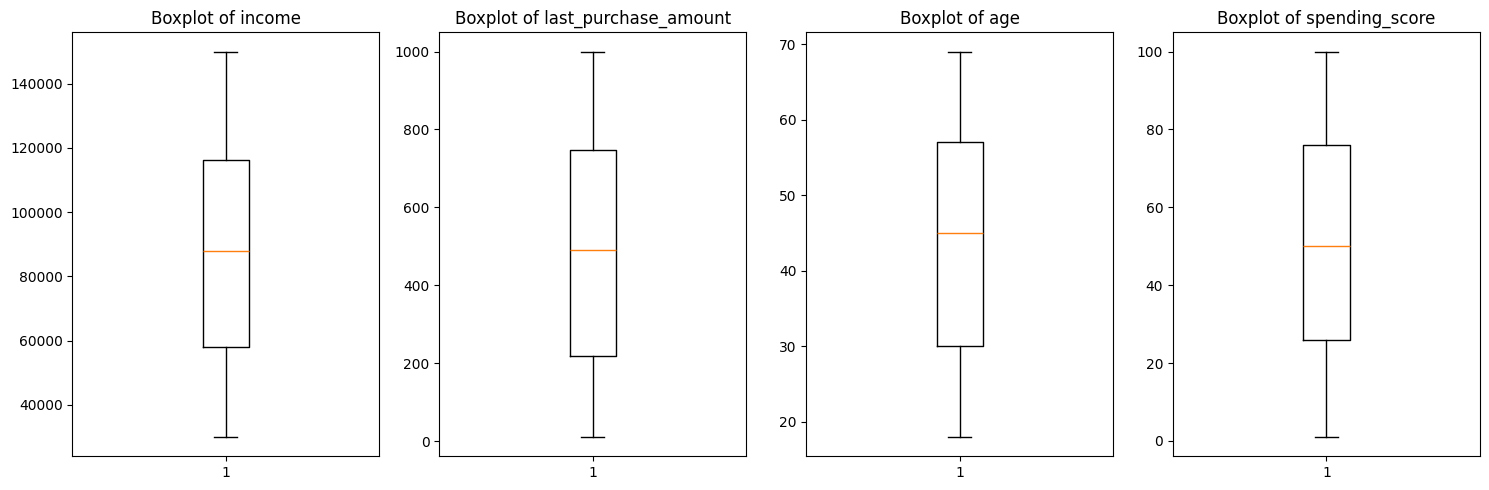

In [ ]:
fig, axes = plt.subplots(1, len(features), figsize=(15, 5))

for i, feature in enumerate(features):
  axes[i].boxplot(data[feature])
  axes[i].set_title(f'Boxplot of {feature}')

plt.tight_layout()
plt.show()

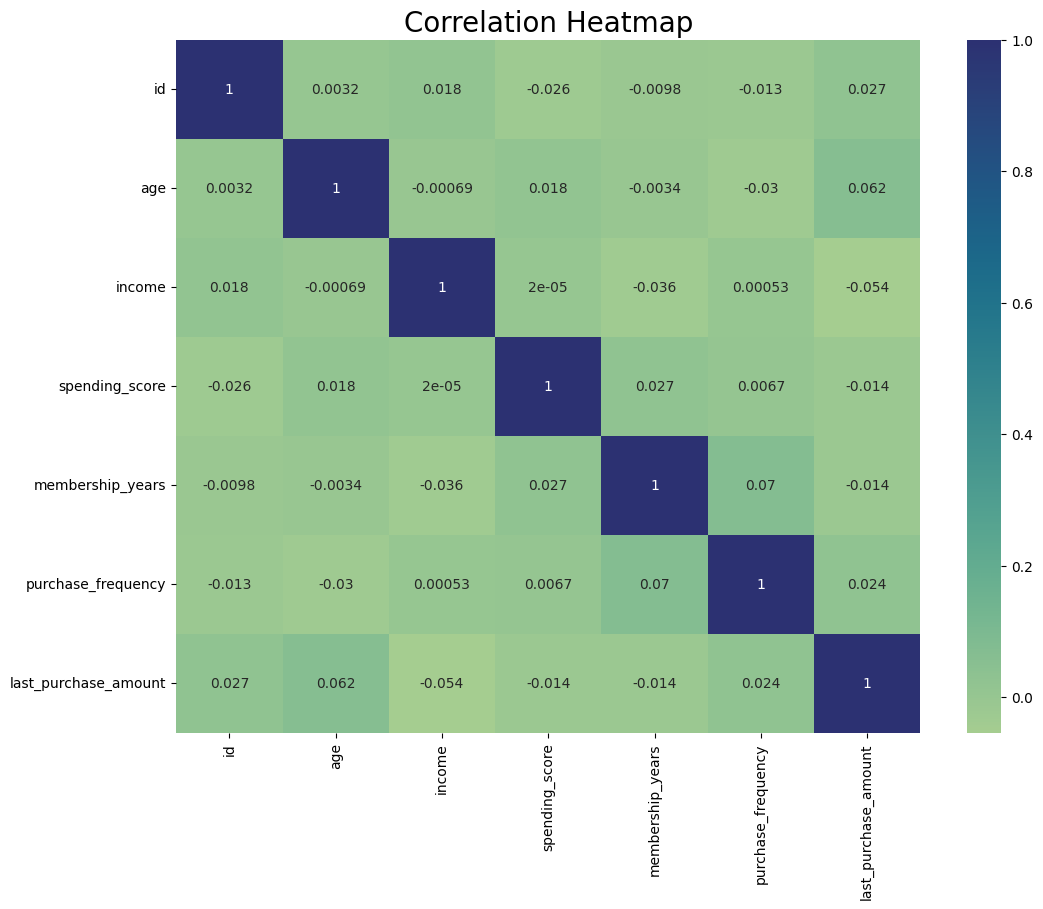

In [ ]:
plt.figure(figsize=(12,9))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap="crest")
plt.title('Correlation Heatmap',fontsize=20)
plt.show()

##Feature Engineering
Before we can apply K-means clustering, we need to transform our categorical variables into numerical representations. K-means operates by calculating distances between points in a multi-dimensional space, so all features must be numeric.

As there are no train/test split I'll use get_dummies()

In [ ]:
df = data.copy()
df.drop('id', axis=1, inplace=True)
df.head()

,age,gender,income,spending_score,membership_years,purchase_frequency,preferred_category,last_purchase_amount
0,38,Female,99342,90,3,24,Groceries,113.53
1,21,Female,78852,60,2,42,Sports,41.93
2,60,Female,126573,30,2,28,Clothing,424.36
3,40,Other,47099,74,9,5,Home & Garden,991.93
4,65,Female,140621,21,3,25,Electronics,347.08


In [ ]:
numeric_cols = ['age', 'income', 'spending_score',
                'membership_years', 'purchase_frequency',
                'last_purchase_amount']

#Scaling Data

In [ ]:
scaler = StandardScaler()
df_scaled = pd.DataFrame(
        scaler.fit_transform(df[numeric_cols]),
        columns=numeric_cols)
df_scaled

,age,income,spending_score,membership_years,purchase_frequency,last_purchase_amount
0,-0.384644,0.316868,1.358468,-0.865010,-0.182348,-1.281540
1,-1.515362,-0.282016,0.321865,-1.215358,1.082005,-1.523763
2,1.078639,1.112778,-0.714738,-1.215358,0.098620,-0.230005
3,-0.251618,-1.210096,0.805613,1.237080,-1.516943,1.690080
4,1.411203,1.523374,-1.025718,-0.865010,-0.112106,-0.491443
...,...,...,...,...,...,...
995,0.879100,0.691806,0.218205,0.186035,-1.797910,-0.604570
996,-1.382336,-0.677034,0.874720,1.587428,-0.252590,0.475247
997,-1.382336,0.718900,-0.369203,-0.164313,1.082005,-1.411583
998,-1.448849,0.736379,0.425525,0.536383,1.222489,0.043341


In [ ]:
df_scaled.describe()

,age,income,spending_score,membership_years,purchase_frequency,last_purchase_amount
count,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03
mean,-7.105427e-17,-8.260059e-17,-7.815970e-17,-1.145750e-16,-1.065814e-17,-9.681145e-17
std,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00
min,-1.714901e+00,-1.709750e+00,-1.716787e+00,-1.565707e+00,-1.797910e+00,-1.630428e+00
25%,-9.167465e-01,-8.940598e-01,-8.529512e-01,-8.650101e-01,-8.145243e-01,-9.255398e-01
50%,8.094613e-02,-1.915317e-02,-2.366909e-02,-1.643134e-01,2.837770e-02,-2.549659e-03
75%,8.791003e-01,8.069717e-01,8.747199e-01,8.867317e-01,8.712797e-01,8.620585e-01
max,1.677254e+00,1.796716e+00,1.704002e+00,1.587428e+00,1.643940e+00,1.716501e+00


In [ ]:
# verify scaling work
print('Mean (should be ~0):')
print(df_scaled.mean().round(2))
print('\nStd (should be ~1):')
print(df_scaled.std().round(2))

Mean (should be ~0):
age                    -0.0
income                 -0.0
spending_score         -0.0
membership_years       -0.0
purchase_frequency     -0.0
last_purchase_amount   -0.0
dtype: float64

Std (should be ~1):
age                     1.0
income                  1.0
spending_score          1.0
membership_years        1.0
purchase_frequency      1.0
last_purchase_amount    1.0
dtype: float64


###Finding how many clusters we would like to have.
[Within Clusters Sum of Squares(WCSS) AND Elbow Method AND Silhouette Score.]

In [ ]:
wcss = []
scores = {}

for i in range(2, 7):
  kmeans_model = KMeans(n_clusters=i, random_state=42)
  labels = kmeans_model.fit_predict(df_scaled)
  wcss.append(kmeans_model.inertia_)
  scores[i] = silhouette_score(df_scaled, labels)

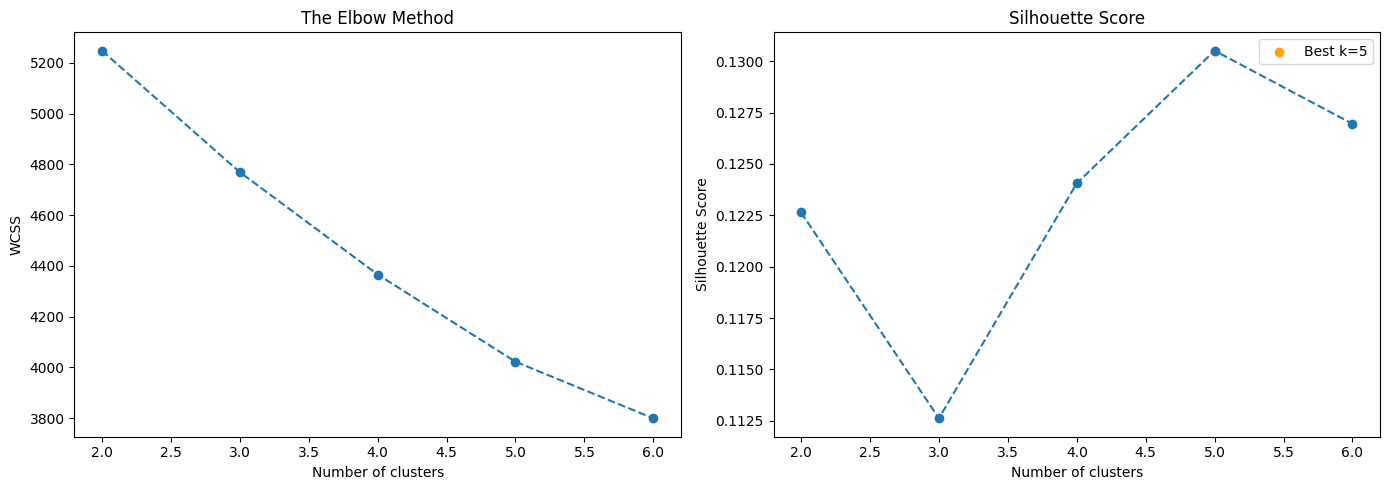

In [ ]:
# Plot both curves side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(2, 7), wcss, marker='o', linestyle='--')
axes[0].set_title('The Elbow Method')
axes[0].set_xlabel('Number of clusters')
axes[0].set_ylabel('WCSS')

best_k = max(scores, key=scores.get)
axes[1].plot(scores.keys(), scores.values(), marker='o', linestyle='--')
axes[1].scatter(best_k, scores[best_k], color='orange', label=f'Best k={best_k}')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of clusters')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()

plt.tight_layout()
plt.show()

##Building the K-Means Clustering Model

In [ ]:
model = KMeans(n_clusters=best_k, random_state=42)
model.fit_predict(df_scaled)

array([4, 4, 1, 3, 1, 0, 4, 2, 3, 3, 0, 3, 4, 3, 0, 1, 1, 0, 4, 4, 0, 4,
       0, 4, 3, 4, 1, 0, 4, 0, 0, 3, 0, 4, 3, 0, 4, 2, 4, 0, 0, 1, 0, 2,
       3, 1, 1, 4, 4, 2, 4, 4, 2, 4, 3, 0, 1, 2, 0, 0, 0, 4, 3, 1, 0, 0,
       4, 4, 4, 3, 4, 3, 0, 4, 1, 2, 3, 4, 0, 3, 2, 1, 4, 4, 0, 4, 3, 4,
       0, 3, 0, 2, 1, 1, 4, 4, 1, 3, 0, 4, 1, 4, 4, 1, 0, 2, 0, 3, 4, 3,
       0, 2, 1, 0, 1, 2, 2, 3, 2, 3, 2, 4, 4, 4, 3, 4, 3, 4, 3, 2, 3, 1,
       2, 4, 4, 2, 4, 2, 4, 4, 4, 4, 2, 0, 2, 3, 1, 2, 4, 1, 2, 1, 3, 0,
       2, 0, 3, 3, 2, 0, 1, 2, 4, 2, 1, 3, 4, 4, 4, 3, 0, 0, 2, 3, 4, 0,
       1, 1, 4, 0, 4, 2, 4, 4, 4, 2, 1, 1, 2, 0, 4, 1, 3, 2, 3, 1, 4, 4,
       1, 1, 2, 3, 1, 1, 2, 0, 3, 1, 1, 1, 4, 0, 2, 0, 2, 0, 0, 1, 3, 2,
       1, 3, 2, 1, 1, 4, 2, 1, 4, 3, 4, 1, 1, 0, 0, 4, 3, 2, 2, 2, 4, 2,
       0, 2, 0, 0, 3, 4, 2, 1, 1, 0, 1, 2, 4, 3, 0, 0, 1, 3, 4, 3, 2, 3,
       2, 2, 2, 0, 4, 4, 3, 1, 2, 2, 2, 0, 3, 3, 0, 3, 3, 0, 2, 1, 1, 1,
       0, 1, 2, 0, 3, 3, 3, 0, 2, 1, 1, 1, 1, 1, 1,

In [ ]:
#Adding the cluster assigment to the original dataframe and the scaled dataframe
df["Cluster"] = model.labels_
df_scaled["Cluster"] = model.labels_

df.head()

,age,gender,income,spending_score,membership_years,purchase_frequency,preferred_category,last_purchase_amount,Cluster
0,38,Female,99342,90,3,24,Groceries,113.53,4
1,21,Female,78852,60,2,42,Sports,41.93,4
2,60,Female,126573,30,2,28,Clothing,424.36,1
3,40,Other,47099,74,9,5,Home & Garden,991.93,3
4,65,Female,140621,21,3,25,Electronics,347.08,1


In [ ]:
df_seg_analysis = df[numeric_cols + ['Cluster']].groupby('Cluster').mean().round(2)
df_seg_analysis

,age,income,spending_score,membership_years,purchase_frequency,last_purchase_amount
Cluster,,,,,,
0,29.62,89683.72,31.44,3.76,23.46,593.72
1,55.32,105414.21,35.83,5.13,21.91,241.50
2,47.03,118629.58,65.29,6.77,32.22,724.35
3,55.26,53376.18,50.05,5.30,28.17,695.30
4,32.73,76448.86,70.28,6.38,27.55,246.07


In [ ]:
df['Cluster'].value_counts()

,count
Cluster,
4,214
1,203
0,199
3,194
2,190


##Visualizing the Clusters

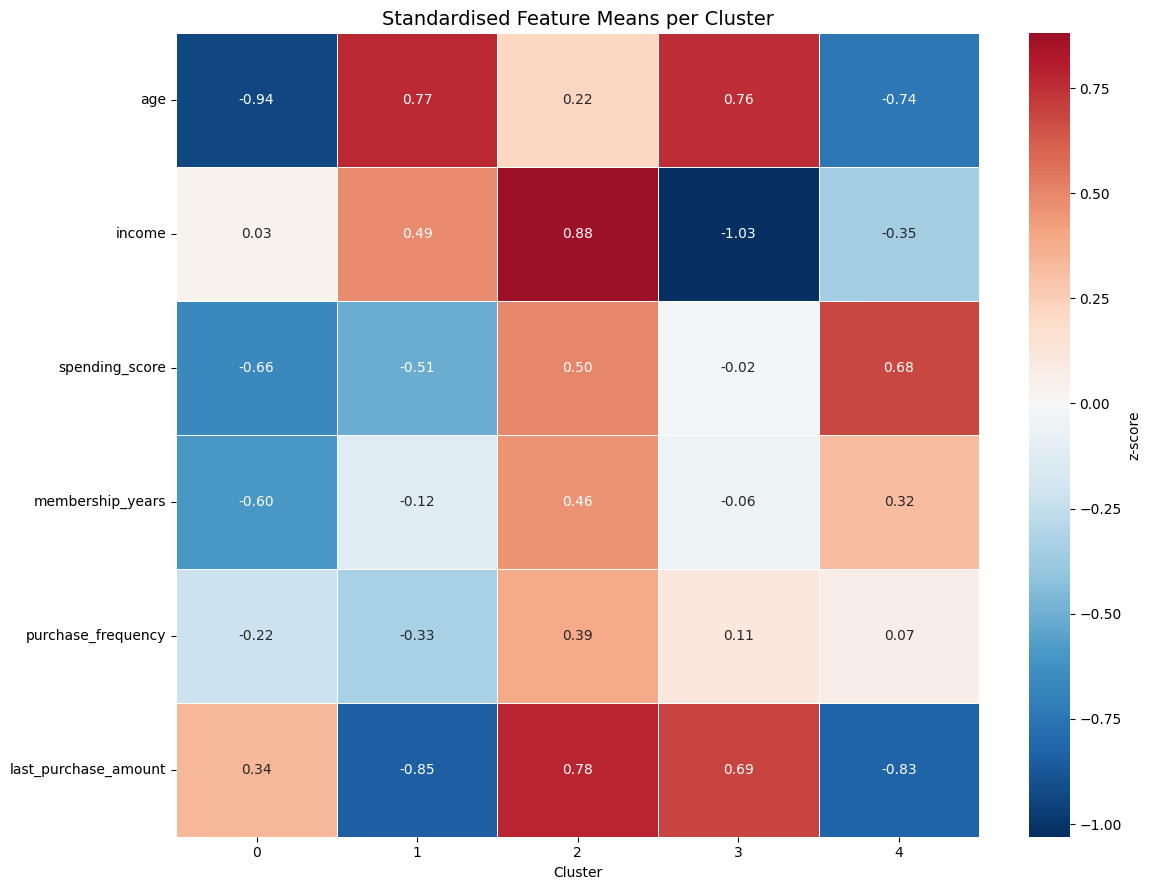

In [ ]:
# Standardised heatmap: z-score mean per cluster per feature.

z_profile = df_scaled.groupby('Cluster')[numeric_cols].mean().round(2)

plt.figure(figsize=(12,9))
sns.heatmap(z_profile.T, annot=True, cmap='RdBu_r',center=0,
            fmt='.2f', linewidths=0.5,cbar_kws={'label': 'z-score'})
plt.title('Standardised Feature Means per Cluster', fontsize=14)
plt.tight_layout()
plt.show()

###Random Forest — predict cluster labels from features, rank by importance

In [ ]:
X_fi = df[numeric_cols]
y_fi = df['Cluster']

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_fi, y_fi)

RandomForestClassifier(random_state=42)

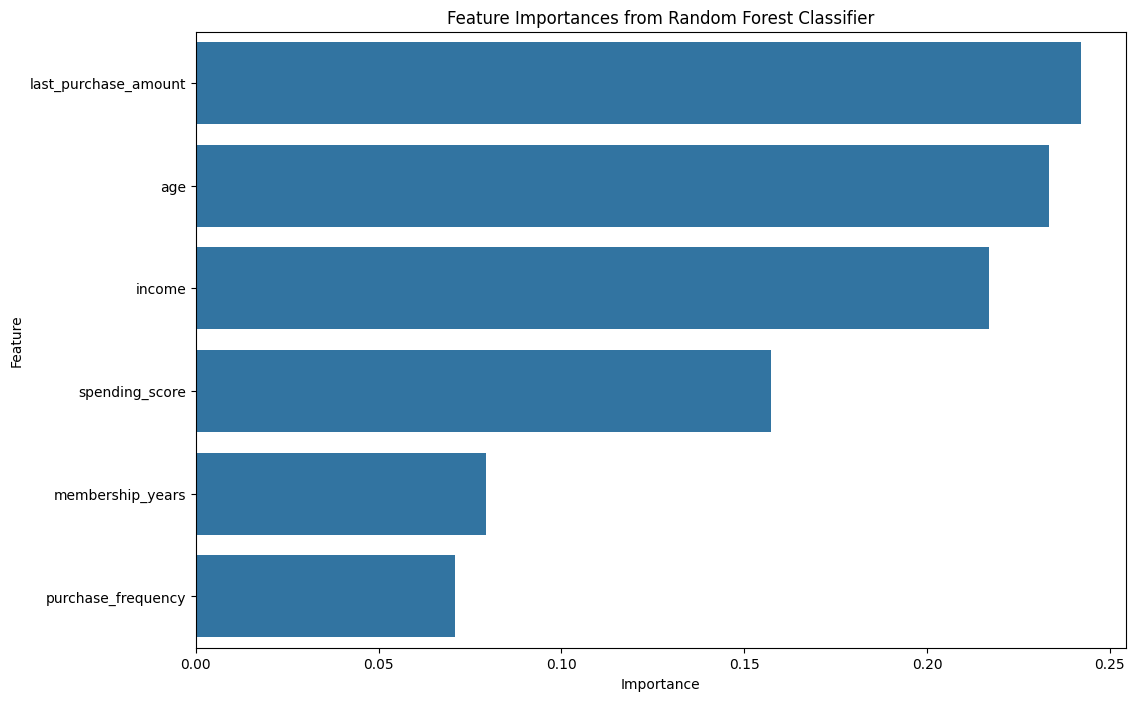

In [ ]:
feature_importances = pd.DataFrame({
    'Feature': X_fi.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importances)
plt.title('Feature Importances from Random Forest Classifier')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

##PCA Visualization

In [ ]:
pca = PCA(n_components=2, random_state=42)
df_pca = pd.DataFrame(
    pca.fit_transform(df_scaled.drop('Cluster', axis=1)),
    columns=['PC1', 'PC2'])

var1 = pca.explained_variance_ratio_[0]
var2 = pca.explained_variance_ratio_[1]
print(f'Variance explained: PC1={var1:.1%}, PC2={var2:.1%}, Total={var1+var2:.1%}')

Variance explained: PC1=18.2%, PC2=18.0%, Total=36.2%


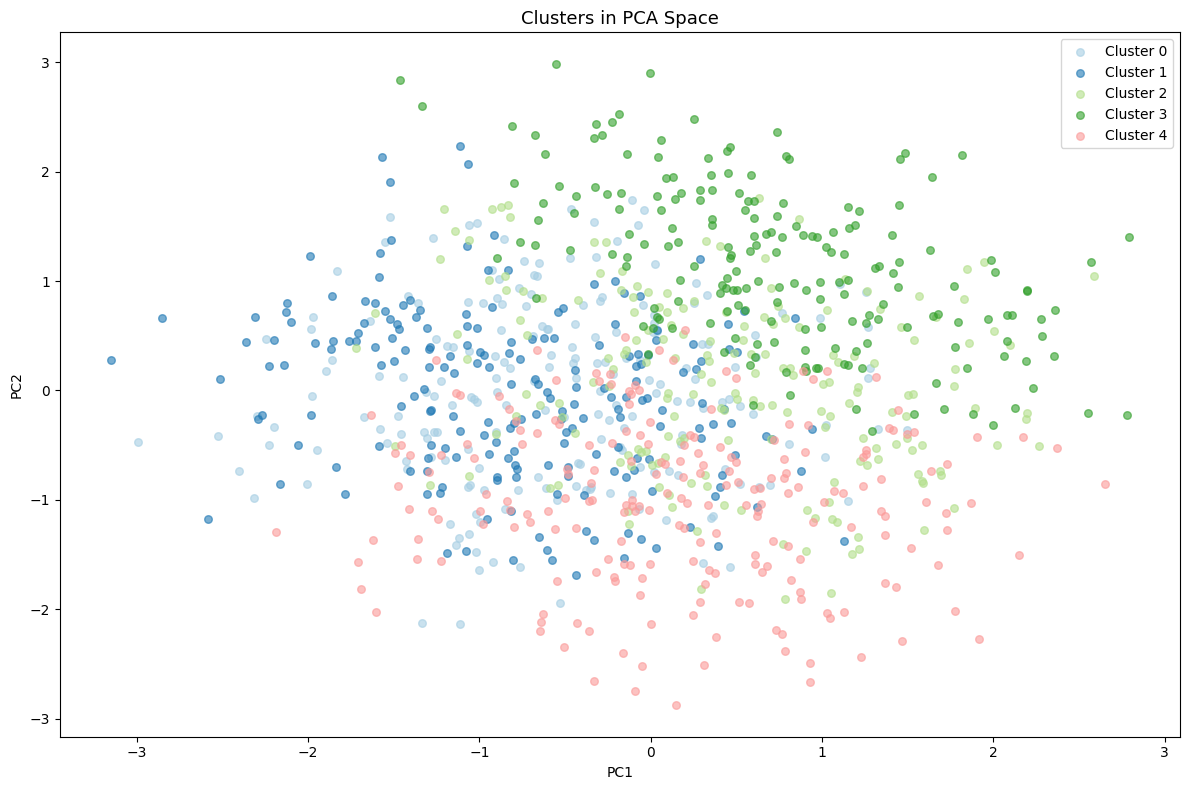

In [ ]:
palette = sns.color_palette("Paired", best_k)

plt.figure(figsize=(12, 8))

for c in sorted(df_scaled['Cluster'].unique()):
  mask = df_scaled['Cluster'] == c
  plt.scatter(df_pca.loc[mask, 'PC1'], df_pca.loc[mask, 'PC2'],
              label=f'Cluster {c}', color=palette[c], alpha=0.6, s=30)

plt.title('Clusters in PCA Space', fontsize=13)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.tight_layout()
plt.show()

##Cluster Naming

In [ ]:
for c in sorted(df_scaled['Cluster'].unique()):
    row = df_seg_analysis.loc[c]
    print(f'\nCluster {c}')
    print(f'  Age: {row["age"]:.0f} | Income: ${row["income"]:,.0f} | '
          f'Spending Score: {row["spending_score"]:.0f}')
    print(f'  Membership years: {row["membership_years"]:.1f} | '
          f'Visits/month: {row["purchase_frequency"]:.1f} | '
          f'Last purchase: ${row["last_purchase_amount"]:,.0f}')


Cluster 0
  Age: 30 | Income: $89,684 | Spending Score: 31
  Membership years: 3.8 | Visits/month: 23.5 | Last purchase: $594

Cluster 1
  Age: 55 | Income: $105,414 | Spending Score: 36
  Membership years: 5.1 | Visits/month: 21.9 | Last purchase: $242

Cluster 2
  Age: 47 | Income: $118,630 | Spending Score: 65
  Membership years: 6.8 | Visits/month: 32.2 | Last purchase: $724

Cluster 3
  Age: 55 | Income: $53,376 | Spending Score: 50
  Membership years: 5.3 | Visits/month: 28.2 | Last purchase: $695

Cluster 4
  Age: 33 | Income: $76,449 | Spending Score: 70
  Membership years: 6.4 | Visits/month: 27.6 | Last purchase: $246
